Dataset Shape: (1025, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  


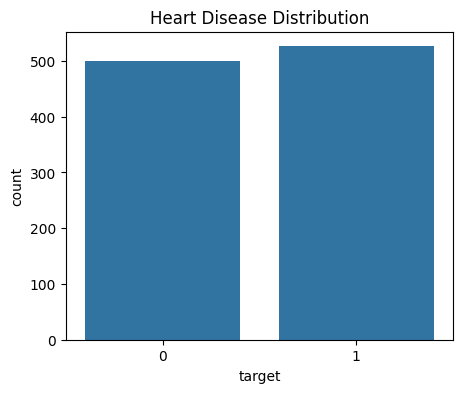

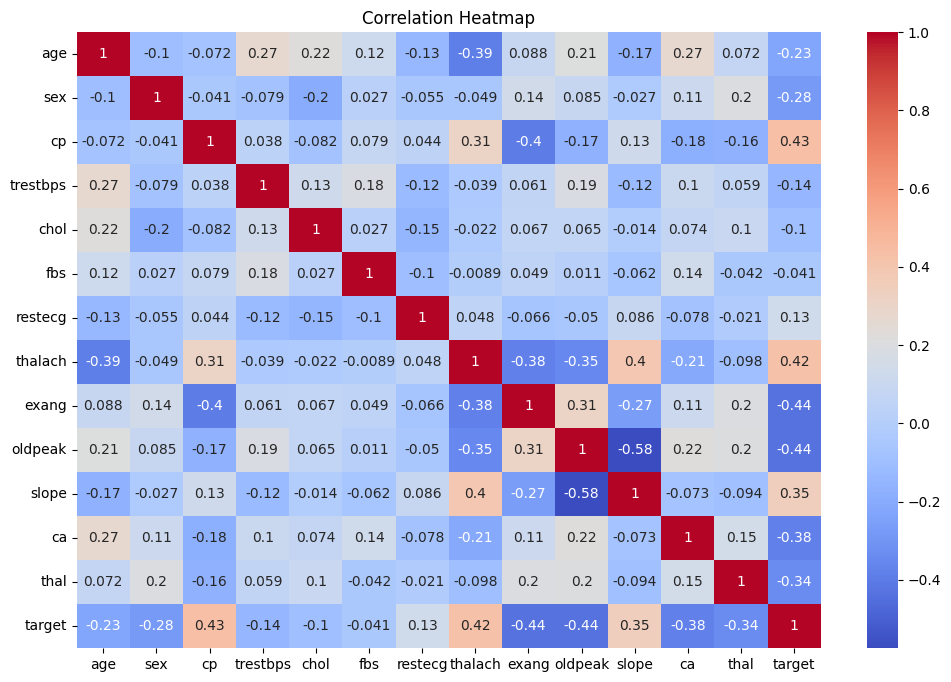

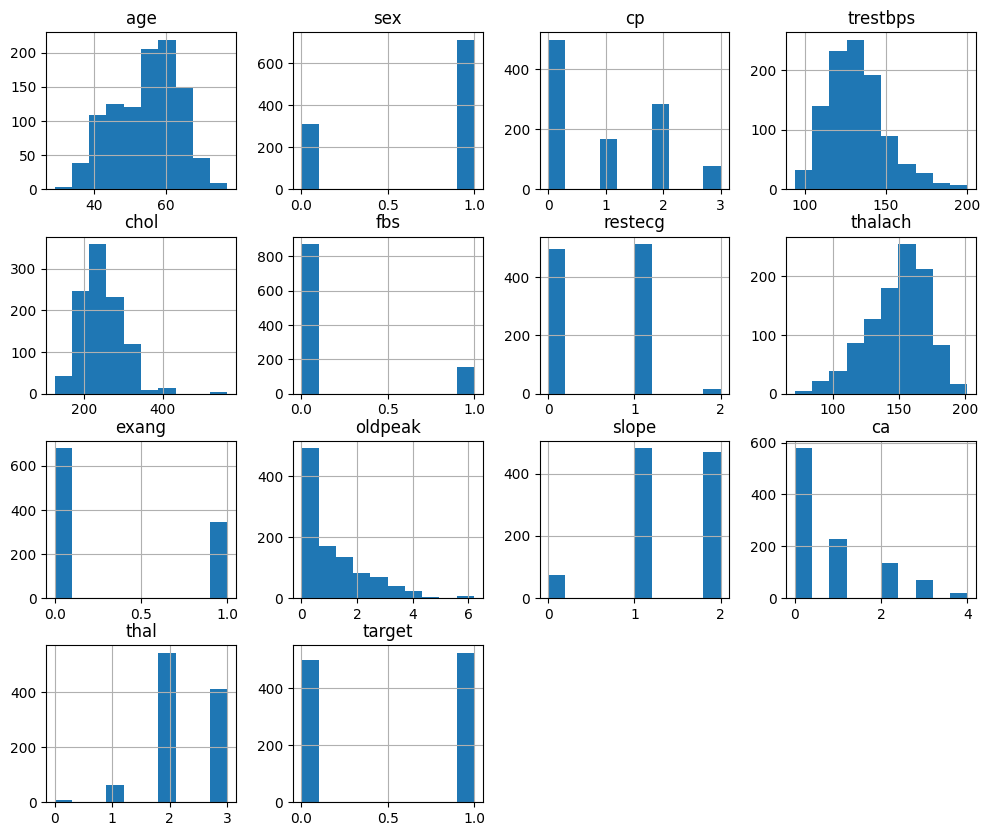

Class Distribution After SMOTE: [526 526]

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.84      0.76      0.79        94
           1       0.82      0.88      0.85       117

    accuracy                           0.82       211
   macro avg       0.83      0.82      0.82       211
weighted avg       0.83      0.82      0.82       211

ROC-AUC: 0.8178305146390253

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00       117

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

ROC-AUC: 1.0

XGBoost Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        94
           1       1.00      1.00      1.00       117

    accuracy                  

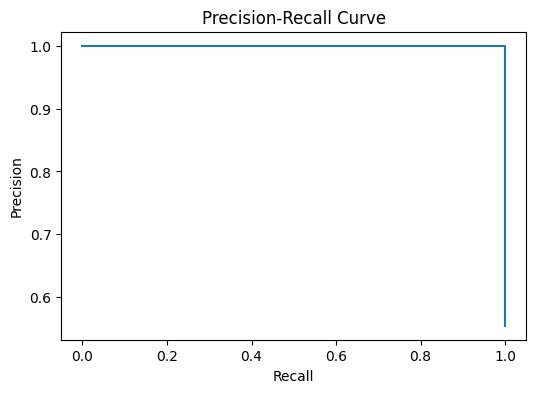

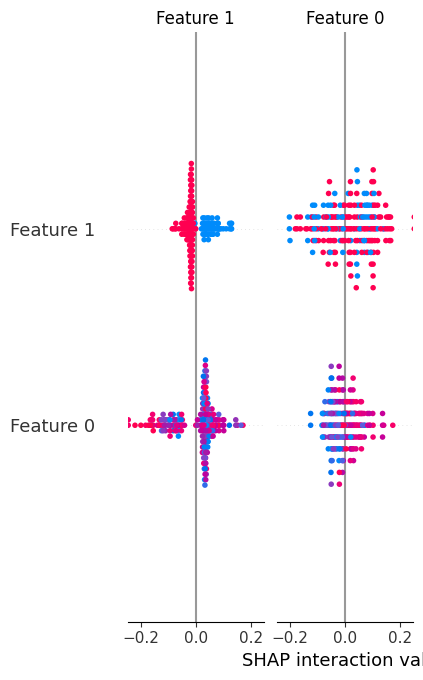


Heart Disease Prediction Project Completed Successfully


In [4]:
# ==========================================================
# HEART DISEASE PREDICTION USING MACHINE LEARNING
# ==========================================================

# -----------------------------
# 1. Import Libraries
# -----------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap


# -----------------------------
# 2. Load Dataset
# -----------------------------

df = pd.read_csv("/content/heart.csv")

print("Dataset Shape:", df.shape)
print(df.head())


# -----------------------------
# 3. Data Overview
# -----------------------------

print("\nDataset Info")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())


# -----------------------------
# 4. Exploratory Data Analysis
# -----------------------------

# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Feature distributions
df.hist(figsize=(12,10))
plt.show()


# -----------------------------
# 5. Feature & Target
# -----------------------------

X = df.drop("target", axis=1)
y = df["target"]


# -----------------------------
# 6. Handle Class Imbalance
# -----------------------------

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class Distribution After SMOTE:", np.bincount(y_resampled))


# -----------------------------
# 7. Train Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)


# -----------------------------
# 8. Standardize Features
# -----------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# -----------------------------
# 9. Logistic Regression
# -----------------------------

log_model = LogisticRegression(max_iter=500)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("\nLogistic Regression Results")
print(classification_report(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_pred))


# -----------------------------
# 10. Random Forest
# -----------------------------

rf_model = RandomForestClassifier(n_estimators=100)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\nRandom Forest Results")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_pred))


# -----------------------------
# 11. XGBoost
# -----------------------------

xgb_model = XGBClassifier()

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("\nXGBoost Results")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_pred))


# -----------------------------
# 12. Precision-Recall Curve
# -----------------------------

precision, recall, _ = precision_recall_curve(y_test, rf_pred)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


# -----------------------------
# 13. SHAP Feature Importance
# -----------------------------

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# -----------------------------
# 14. Project Completed
# -----------------------------

print("\nHeart Disease Prediction Project Completed Successfully")